# KNN

1) Import Necessary Package

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, average_precision_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV



OUTPUT_DIR = "../outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

2. Data Preparation for Modelling

In [62]:
# read the processed dataset
df = pd.read_csv(r"../data/processed/feature_engineered_with_SLM.csv")

In [63]:
# print the shape of the dataset
df.shape

(1200, 33)

In [64]:
pd.set_option('display.max_columns', None)
# dislay first 5 rows of the dataset
df.head()

,transaction_id,customer_id,transaction_datetime,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,is_fraud,transaction_note,slm_risk_score,slm_urgency,slm_anomaly_category,txn_hour,txn_dayofweek,txn_week,is_weekend,is_night,prev_txn_time,txn_gap_minutes,txn_7d_count,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,998,1000,2022-10-05 15:13:00,US,mobile_app,luxury,672.47,23.0,2,3,0,new device,9,high,fraud,15,2,40,0,0,NaN,-1.000000,NaN,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,953,1000,2023-02-05 06:18:18,US,web,gaming,2593.31,84.0,0,0,1,overnight shipping,8,high,fraud,6,6,5,1,0,2022-10-05 15:13:00,176585.300000,NaN,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,94,1000,2023-03-23 18:04:02,US,pos_terminal,electronics,302.22,70.0,3,1,0,high value item,9,high,fraud,18,3,12,0,0,2023-02-05 06:18:18,66945.733333,NaN,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2
3,457,1000,2023-04-05 00:14:27,US,mobile_app,gaming,4395.07,24.0,0,2,0,repeat purchase,9,high,fraud,0,2,14,0,1,2023-03-23 18:04:02,17650.416667,NaN,1,2,1931.283333,1662.07937,1.482352,0,1,0,7.333333,2
4,1199,1000,2023-07-13 02:02:46,US,mobile_app,luxury,579.99,23.0,1,0,0,overnight shipping,5,low,unknown,2,3,28,0,1,2023-04-05 00:14:27,142668.316667,NaN,1,2,1931.283333,1662.07937,-0.813014,0,1,0,5.555556,0


In [65]:
# check the distribution of the target variable
df['is_fraud'].value_counts()

is_fraud
0    1119
1      81
Name: count, dtype: int64

In [66]:
# check positive rate
print("Positive rate:", df['is_fraud'].mean())

Positive rate: 0.0675


3. Split Data

In [67]:
# define variables and drop unnecessary columns
X = df.drop(columns=['is_fraud', 'transaction_id', 'customer_id', 'transaction_datetime','prev_txn_time','txn_7d_count','transaction_note'])
y = df['is_fraud']


In [68]:
# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


4. Preprocess

In [69]:
# identify categorical and numerical columns
categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

In [70]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ], remainder="drop")



In [71]:
X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)

print(X_train.shape)
print(X_test.shape)


(960, 37)
(240, 37)


5. Model Training + Evaluation

Baseline Test Accuracy (k=5): 0.88


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,kNN_baseline,0.879167,0.066667,0.0625,0.064516,0.5,0.066667



Baseline kNN Classification Report:
              precision    recall  f1-score   support

           0     0.9333    0.9375    0.9354       224
           1     0.0667    0.0625    0.0645        16

    accuracy                         0.8792       240
   macro avg     0.5000    0.5000    0.5000       240
weighted avg     0.8756    0.8792    0.8774       240



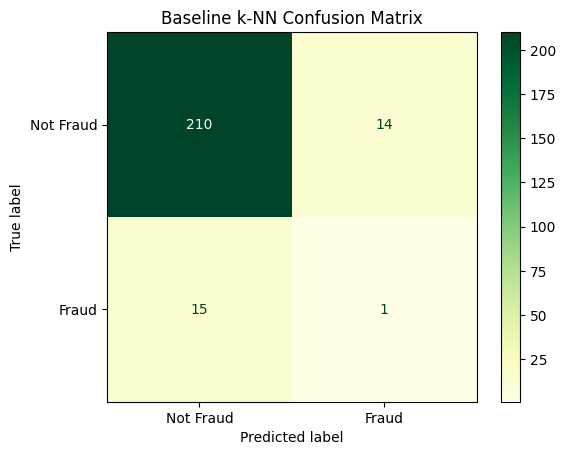

In [72]:
# Train baseline KNN classifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred_baseline = knn.predict(X_test)
y_proba_baseline = knn.predict_proba(X_test)[:, 1]
print(f"Baseline Test Accuracy (k=5): {accuracy_score(y_test, y_pred_baseline):.2f}")

baseline_metrics = {
    "model": "kNN_baseline",
    "accuracy": accuracy_score(y_test, y_pred_baseline),
    "precision": precision_score(y_test, y_pred_baseline, zero_division=0),
    "recall": recall_score(y_test, y_pred_baseline, zero_division=0),
    "f1": f1_score(y_test, y_pred_baseline, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_baseline),
    "pr_auc": average_precision_score(y_test, y_proba_baseline)
}
display(pd.DataFrame([baseline_metrics]))

print("\nBaseline kNN Classification Report:")
print(classification_report(y_test, y_pred_baseline, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap="YlGn")
plt.title("Baseline k-NN Confusion Matrix")
plt.savefig(os.path.join(FIG_DIR, "kNN_baseline_confusion_matrix.png"), dpi=200)
plt.show()




In [73]:
# grid search for hyperparameter tuning
param_grid = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # Manhattan vs Euclidean
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best k:", grid.best_params_['n_neighbors'])

best_knn = grid.best_estimator_


Best k: 19


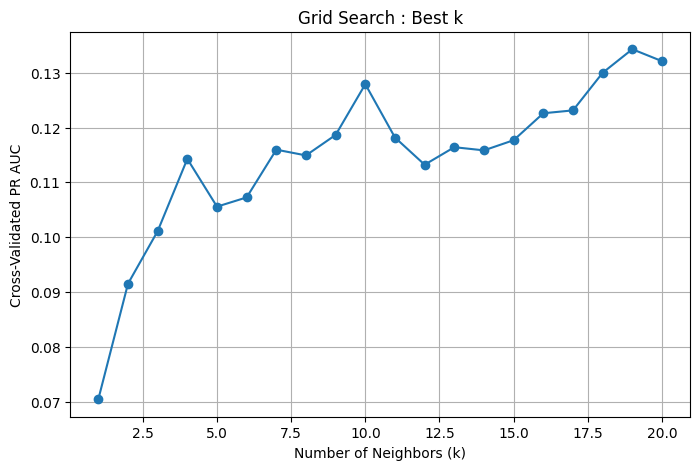

In [74]:
# visualise the grid search results in a plot
results = pd.DataFrame(grid.cv_results_)

subset = results[(results['param_weights'] == 'distance') & (results['param_p'] == 1)]

# Plot mean test scores vs n_neighbors
plt.figure(figsize=(8,5))
plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], marker='o')
plt.title("Grid Search : Best k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated PR AUC")
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "kNN_gridsearch_best_k.png"), dpi=200)
plt.show()


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,kNN_tuned,0.933333,0.0,0.0,0.0,0.487584,0.078836



Classification Report:
              precision    recall  f1-score   support

           0     0.9333    1.0000    0.9655       224
           1     0.0000    0.0000    0.0000        16

    accuracy                         0.9333       240
   macro avg     0.4667    0.5000    0.4828       240
weighted avg     0.8711    0.9333    0.9011       240



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

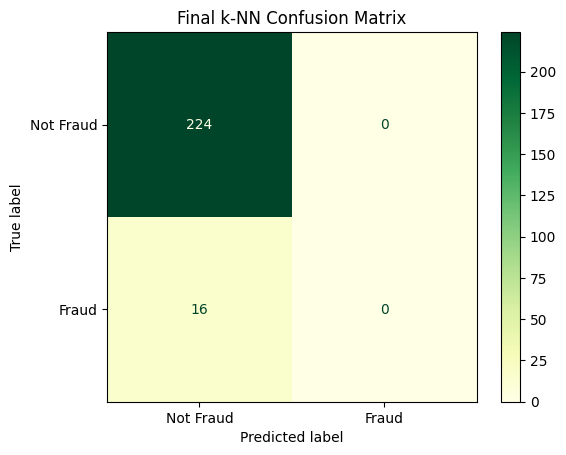

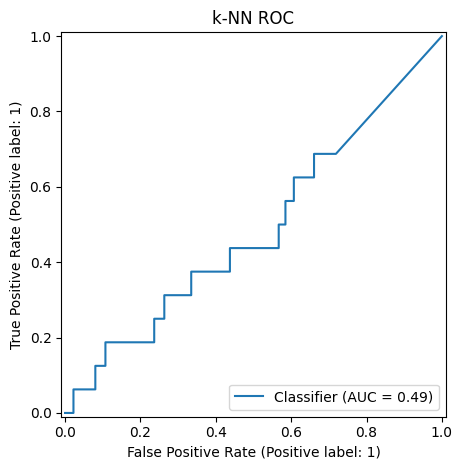

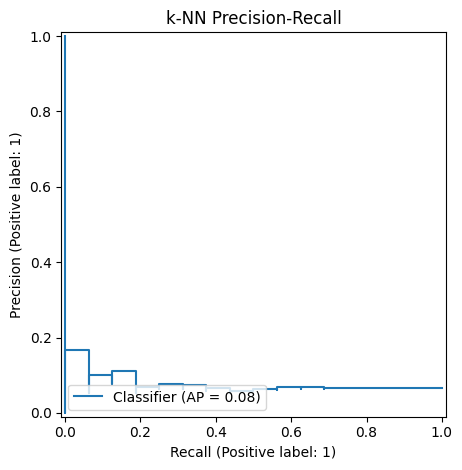

In [75]:
# Predictions
y_pred_tuned = best_knn.predict(X_test)
y_proba_tuned = best_knn.predict_proba(X_test)[:, 1]

# Metrics
tuned_metrics = {
    "model": "kNN_tuned",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_tuned),
    "pr_auc": average_precision_score(y_test, y_proba_tuned)
}
display(pd.DataFrame([tuned_metrics]))



# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap="YlGn")
plt.title("Final k-NN Confusion Matrix")
plt.savefig(os.path.join(FIG_DIR, "kNN_confusion_matrix.png"), dpi=200)
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_tuned)
plt.title("k-NN ROC")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "kNN_roc.png"), dpi=200)
plt.show()

# precision recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_tuned)
plt.title("k-NN Precision-Recall")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "kNN_pr.png"), dpi=200)
plt.show()



In [76]:
# save results in csv file
results_df = pd.DataFrame([baseline_metrics, tuned_metrics])
results_df.to_csv(os.path.join(TAB_DIR, "kNN_results.csv"), index=False)